In [2]:
import json
import re
import matplotlib.pyplot as plt


Load data

In [3]:
with open("competency_questions_output/competency_questions_all_documents.txt", "r", encoding="utf-8") as f:
    txt_cqs = f.read()

pattern = r'\*\*Frage:\*\*\s*(.+?)\s*\*\*Quelle:\*\*\s*(.+?)(?=\n\d+\.\Z|\n\d+\.|\Z)'
entries = re.findall(pattern, txt_cqs, re.DOTALL)

# Separate question and source for processing
questions_only = [q.strip() for q, s in entries]
sources_only = [s.strip() for q, s in entries]

# Deduplicate questions (with mapping)
seen = set()
cqs, sources = [], []
for q, s in zip(questions_only, sources_only):
    if q not in seen:
        seen.add(q)
        cqs.append(q)
        sources.append(s)

with open("clustered_questions/clustered_questions_only_new.json", "r", encoding="utf-8") as f:
    clustered_cqs = json.load(f)

with open("competency_questions_output/generalized_questions_new.json", "r", encoding="utf-8") as f:
    gcqs = json.load(f)

with open("ontology_output/gcq_ontology_topdown_refined_source.json", "r", encoding="utf-8") as f:
    ontology_refined = json.load(f)

with open("ontology_output/gcq_ontology_topdown_source.json", "r", encoding="utf-8") as f:
    ontology = json.load(f)

In [4]:
print(f"Total number of questions: {len(cqs)}")
print(f"Total number of clusters: {len(clustered_cqs)}")
print(f"Size of noice cluster: {len(clustered_cqs['Cluster -1'])}")
clustered_cqs_nn = {k: v for k, v in clustered_cqs.items() if k != "Cluster -1"}
print(f"Average number of questions per cluster: {round(sum(len(v) for v in clustered_cqs_nn.values()) / len(clustered_cqs_nn), 2)}")
print(f"Min questions in a cluster: {min(len(v) for v in clustered_cqs_nn.values())}")
print(f"Max questions in a cluster: {max(len(v) for v in clustered_cqs_nn.values())}")
total_classes_ref = sum(len(cluster.get("refined_ontology", {}).get("classes", [])) for cluster in ontology_refined.values())
total_properties_ref = sum(len(cluster.get("refined_ontology", {}).get("relationships", [])) for cluster in ontology_refined.values())
total_relationships_ref = sum(len(cluster.get("refined_ontology", {}).get("relationships", [])) for cluster in ontology_refined.values())
print(f"Average classes per refined ontology: {round(total_classes_ref/len(ontology_refined), 2)}")
print(f"Average properties per refined ontology: {round(total_properties_ref/len(ontology_refined), 2)}")
print(f"Average relationships per refined ontology: {round(total_relationships_ref/len(ontology_refined), 2)}")
total_classes_base = sum(len(cluster.get("ontology", {}).get("classes", [])) for cluster in ontology.values())
total_properties_base = sum(len(cluster.get("ontology", {}).get("relationships", [])) for cluster in ontology.values())
total_relationships_base = sum(len(cluster.get("ontology", {}).get("relationships", [])) for cluster in ontology.values())
print(f"Average classes per base ontology: {round(total_classes_base/len(ontology), 2)}")
print(f"Average properties per base ontology: {round(total_properties_base/len(ontology), 2)}")
print(f"Average relationships per base ontology: {round(total_relationships_base/len(ontology), 2)}")


Total number of questions: 55108
Total number of clusters: 406
Size of noice cluster: 3982
Average number of questions per cluster: 126.24
Min questions in a cluster: 15
Max questions in a cluster: 1559
Average classes per refined ontology: 11.78
Average properties per refined ontology: 12.85
Average relationships per refined ontology: 12.85
Average classes per base ontology: 4.6
Average properties per base ontology: 4.66
Average relationships per base ontology: 4.66


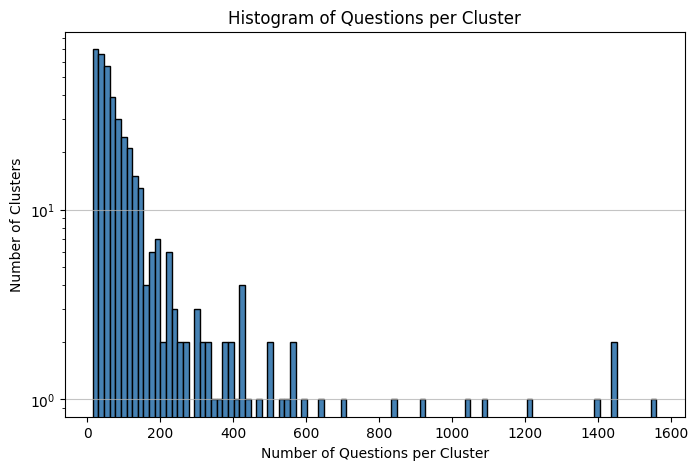

In [ ]:
question_counts = {cluster: len(questions) for cluster, questions in clustered_cqs_nn.items()}
counts = list(question_counts.values())

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(counts, bins=100, color='steelblue', edgecolor='black')
#plt.yscale('log')
plt.xlabel('Number of Questions per Cluster')
plt.ylabel('Number of Clusters')
plt.title('Histogram of Questions per Cluster')
plt.grid(axis='y', alpha=0.75)
plt.show()